# Exploratory Data Analysis (EDA) - Milan

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load the ML Dataset

In [2]:
# Load the Milan noise ML dataset
dataset = pd.read_csv("data/mil_noise_class_ml_dataset.csv")

print(f"Dataset shape: {dataset.shape}")
dataset.head()
print(dataset.columns.tolist())

Dataset shape: (22164, 22)
['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


## Reduce the number of columns

In [3]:
print(dataset.columns.tolist())

['road_id', 'noise_day', 'noise_evening', 'noise_night', 'road_category', 'dist_to_trunk', 'dist_to_primary', 'dist_to_secondary', 'dist_to_tertiary', 'dist_to_residential', 'dist_to_living_street', 'signals', 'transport', 'pois', 'width', 'betweenness', 'closeness_global', 'closeness_400', 'straightness', 'green', 'industrial', 'commercial']


<Axes: >

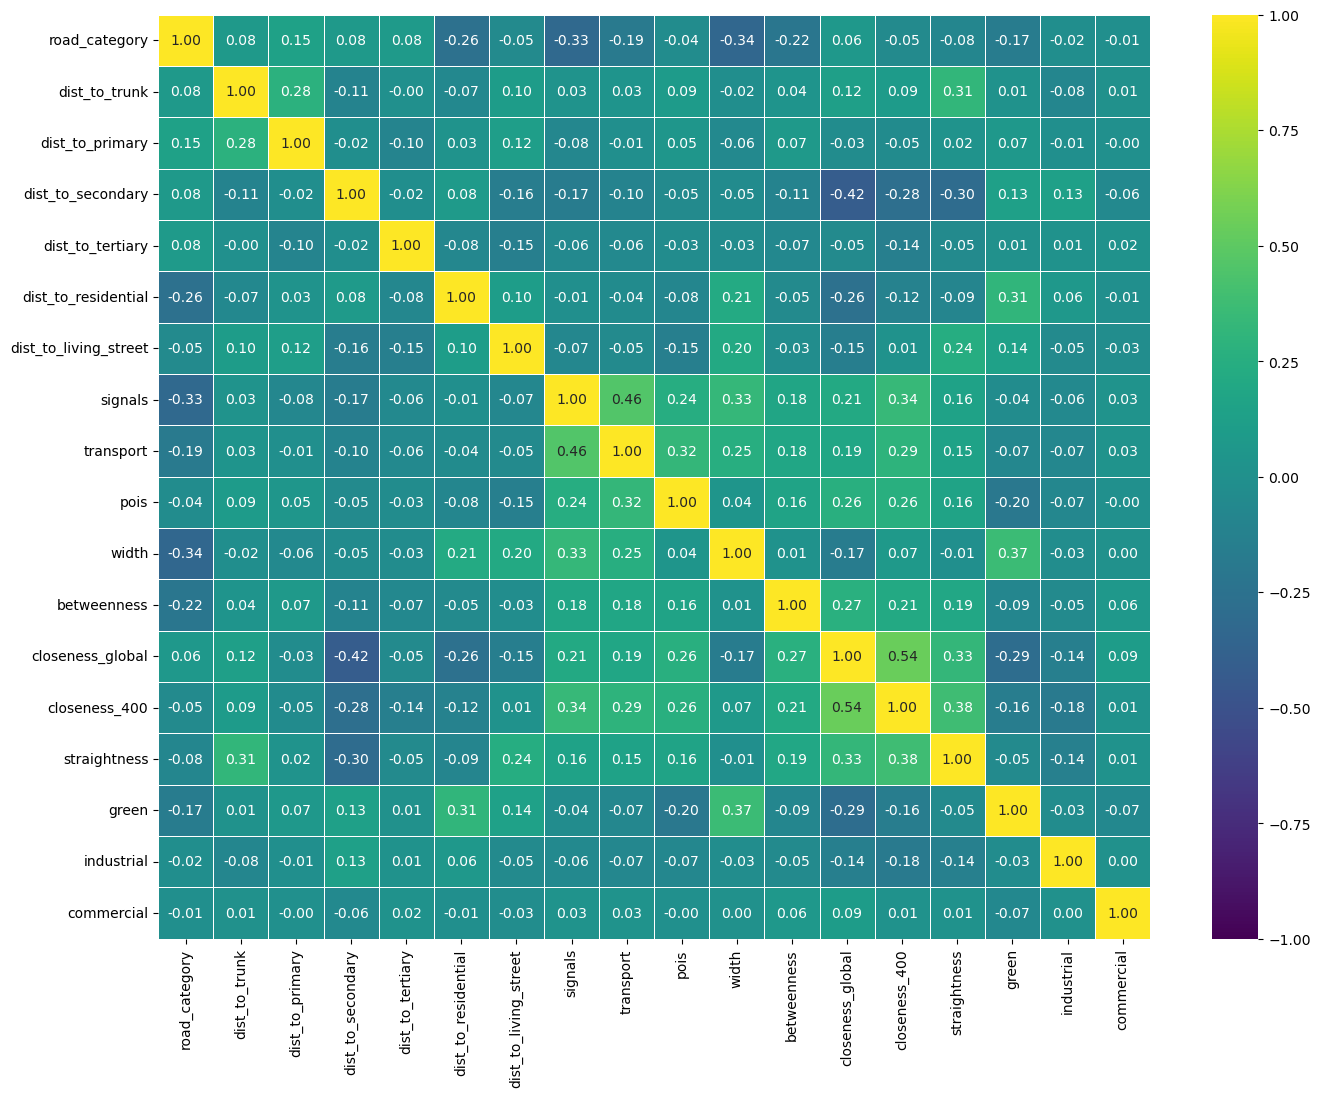

In [4]:
dataset_features = dataset.drop(columns=['road_id', 'noise_day', 'noise_evening', 'noise_night'])
plt.figure(figsize=(16, 12))
sns.heatmap(dataset_features.corr(), center=0, linewidths=0.5,
            cmap="viridis", vmin=-1, vmax=1, annot=True, fmt=".2f")

## Calculate Spearman correlation

Pearson measures linear relationships
-> very sensitive to outliers and nonlinear patterns

Spearman measures rank-order relationships
-> works well with nonlinear relationships and is more robust to outliers

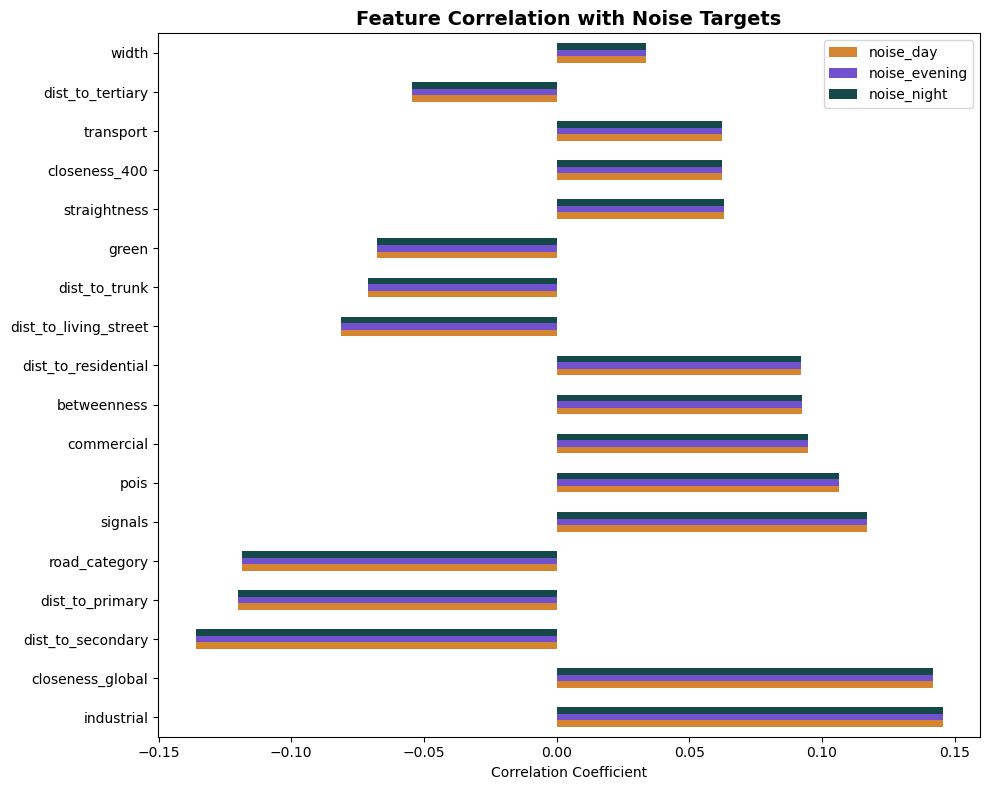

                       noise_day  noise_evening  noise_night
industrial              0.145478       0.145478     0.145478
closeness_global        0.141942       0.141942     0.141942
signals                 0.117047       0.117047     0.117047
pois                    0.106280       0.106280     0.106280
commercial              0.094901       0.094901     0.094901
betweenness             0.092566       0.092566     0.092566
dist_to_residential     0.092152       0.092152     0.092152
straightness            0.063143       0.063143     0.063143
closeness_400           0.062381       0.062381     0.062381
transport               0.062244       0.062244     0.062244
width                   0.033769       0.033769     0.033769
dist_to_tertiary       -0.054581      -0.054581    -0.054581
green                  -0.067861      -0.067861    -0.067861
dist_to_trunk          -0.071039      -0.071039    -0.071039
dist_to_living_street  -0.081310      -0.081310    -0.081310
road_category          -

In [5]:
dataset_filtered = dataset.drop(columns=['road_id'])
target_cols = ['noise_day', 'noise_evening', 'noise_night']
feature_correlation = dataset_filtered.corr(method='spearman')[target_cols].drop(target_cols)

feature_correlation_sorted = feature_correlation.abs().sort_values('noise_day', ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
feature_correlation.loc[feature_correlation_sorted.index].plot(
    kind='barh', ax=ax, color=['#d58430', '#7251ce', '#144849'])
ax.set_title('Feature Correlation with Noise Targets', fontsize=14, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()

print(feature_correlation.sort_values('noise_day', ascending=False))

In [6]:
dataset_pairs = dataset.drop(columns=['road_id', 'noise_evening', 'noise_night'])

sample = dataset_pairs.sample(n=1000, random_state=42).copy()

sorted_noise_values = sorted(sample['noise_day'].unique())
sample['noise_day'] = pd.Categorical(sample['noise_day'], categories=sorted_noise_values, ordered=True)

In [7]:
print("Noise Day values:")
print(dataset['noise_day'].unique())
print("\nUnique values count:", dataset['noise_day'].nunique())

Noise Day values:
[3 2 4]

Unique values count: 3
